<a href="https://colab.research.google.com/github/anujpurohit0501/flipkart-mobile-eda/blob/main/Flipkart_Mobile_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Flipkart Mobiles (EDA)



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**    - Anuj Purohit

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/anujpurohit0501

# **Problem Statement**


To analyze Flipkart mobile phone data and understand patterns in pricing, ratings, and features using data visualization and basic data analysis techniques.

#### **Define Your Business Objective?**

To help understand mobile phone market trends on Flipkart by analyzing pricing, ratings, and features so that better insights can be used for pricing strategy and customer decision-making

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset Loading

In [3]:
# Load Dataset
path='/content/drive/MyDrive/Flipkart_Mobiles.csv'
df=pd.read_csv(path)


### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [5]:
df.tail()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
3109,SAMSUNG,M52 5G,Blazing Black,6 GB,128 GB,4.3,25990,25990
3110,SAMSUNG,M52 5G,Icy Blue,6 GB,128 GB,4.3,25489,28449
3111,SAMSUNG,M52 5G,Icy Blue,8 GB,128 GB,4.3,27239,31489
3112,SAMSUNG,M52 5G,Slate Black,8 GB,128 GB,4.2,22989,22989
3113,SAMSUNG,M52 5G,Sky Blue,8 GB,128 GB,4.2,20350,22595


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
df.shape

(3114, 8)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3071 non-null   object 
 4   Storage         3075 non-null   object 
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(108)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
x=df.isnull().sum()

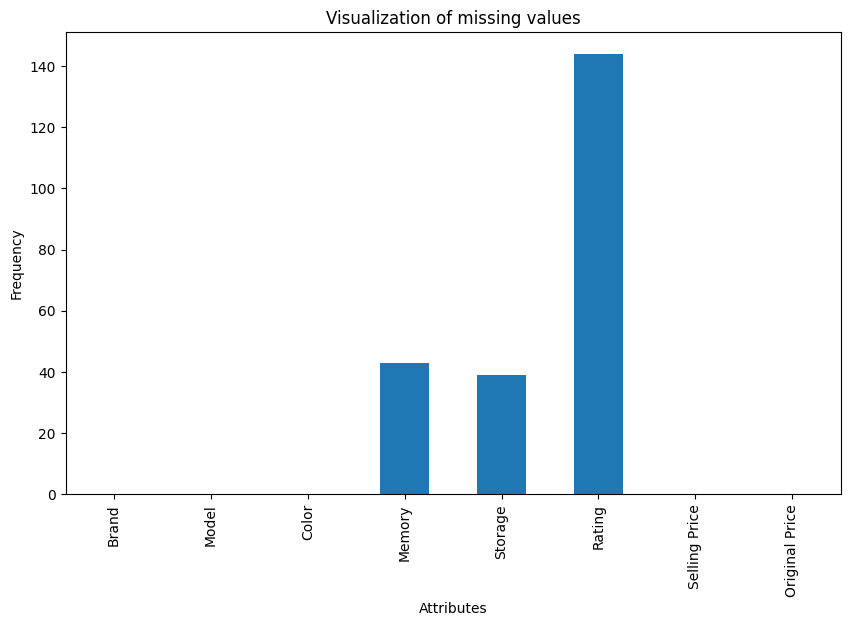

In [10]:
# Visualizing the missing values
plt.figure(figsize=(10,6))
x.plot(kind='bar')
plt.xlabel('Attributes')
plt.ylabel('Frequency')
plt.title('Visualization of missing values')
plt.show()

### What did you know about your dataset?

I found duplicate records and some missing values in certain columns. Visualizing them helped identify data quality issues and guided the cleaning process before analysis.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe()

,Rating,Selling Price,Original Price
count,2970.000000,3114.000000,3114.000000
mean,4.243098,26436.625562,28333.473025
std,0.271991,30066.892622,31525.599889
min,2.300000,1000.000000,1000.000000
25%,4.100000,9990.000000,10030.250000
50%,4.300000,15000.000000,16889.500000
75%,4.400000,28999.000000,31500.000000
max,5.000000,179900.000000,189999.000000


### Variables Description

#### **Brand** : Name of the Mobile Manufacturer (e.g., Samsung, LG, OPPO)

#### **Model** : Phone ka specific model name

#### **Color** : Color of the model

#### **Memory** : RAM of the model

#### **Storage** : ROM of the model

#### **Rating** : Rating of the model based on reviews (out of 5)

#### **Selling Price** : Selling Price/Discounted Price of the model in INR

#### **Original Price** : Actual price of the model in INR


### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
# Counting unique values for each variable(attribute)
df.nunique()



,0
Brand,17
Model,914
Color,639
Memory,26
Storage,26
Rating,25
Selling Price,844
Original Price,819


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.

df=df.dropna()

### What all manipulations have you done and insights you found?

Manipulations done are -

1. Used df.head() to view the first 5 rows and understand the dataset structure.
2. Used df.tail() to inspect the last 5 rows.
3. Used df.shape to identify the total number of rows and columns.
4. Used df.isnull().sum() to count missing values in each column.
5. Used df.columns to check all column names.
6. Used df.dropna() to remove rows containing missing values.
7. Used df.nunique() to find the number of unique values in each column.
8. Used df.duplicated().sum() to detect duplicate records.
9. Used df.describe() to obtain statistical summaries of numerical columns.
10. Visualized missing values using a bar graph to easily identify columns with missing data.


Insights found -

1. Understood the structure of the dataset.
2. Found missing values in some columns.
3. Checked that there were no duplicate rows (or found the number of duplicates).
4. Learned which columns have many unique values.
5. Cleaned the dataset by removing missing values.
6. The dataset is now ready for further analysis and visualization.

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

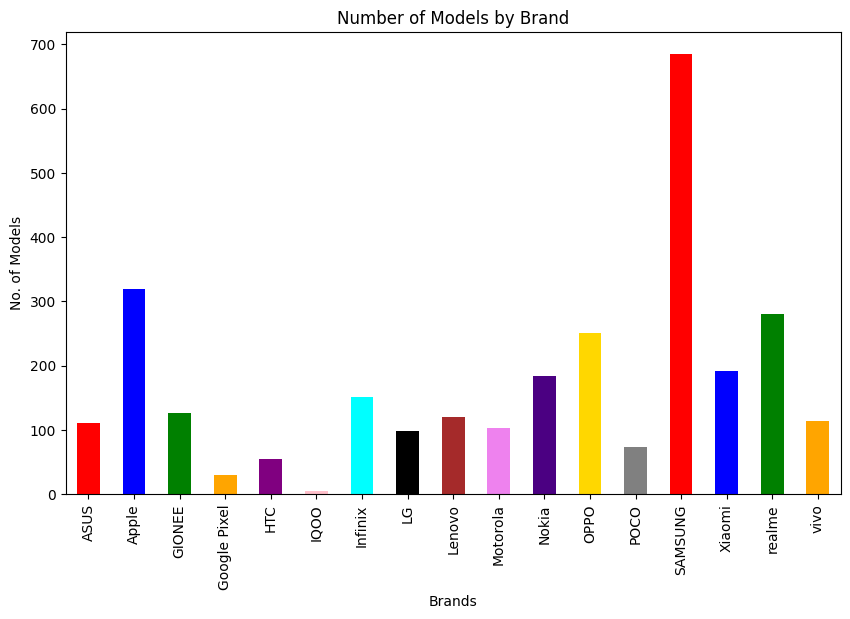

In [15]:
# Chart - 1 visualization code

# Number of Mobiles by Brand
x=df.groupby('Brand').size()
c=['red','blue','green','orange','purple','pink','cyan','black','brown','violet','indigo','gold','grey']
plt.figure(figsize=(10,6))
x.plot(kind='bar',color=c)
plt.xlabel('Brands')
plt.ylabel('No. of Models')
plt.title('Number of Models by Brand')
plt.show()

##### 1. Why did you pick the specific chart?

Answer:
I used a bar chart because it is the best chart to compare the number of mobiles across different brands. It makes the comparison clear and easy to understand.

##### 2. What is/are the insight(s) found from the chart?

Answer :

1. This graph shows how many mobile phones belong to each brand.
2. Some brands have more mobile models than others.
3. The brand with the tallest bar has the highest number of mobiles in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Ans1: Yes.

1. The analysis shows which brands have more mobile models.
2. It helps understand customer choices and market trends.

Ans2: Yes, possibly.

1. Brands with very few mobile models may have lower customer interest.
2. If a brand has fewer products in the dataset, it may indicate lower market presence or demand.


#### Chart - 2

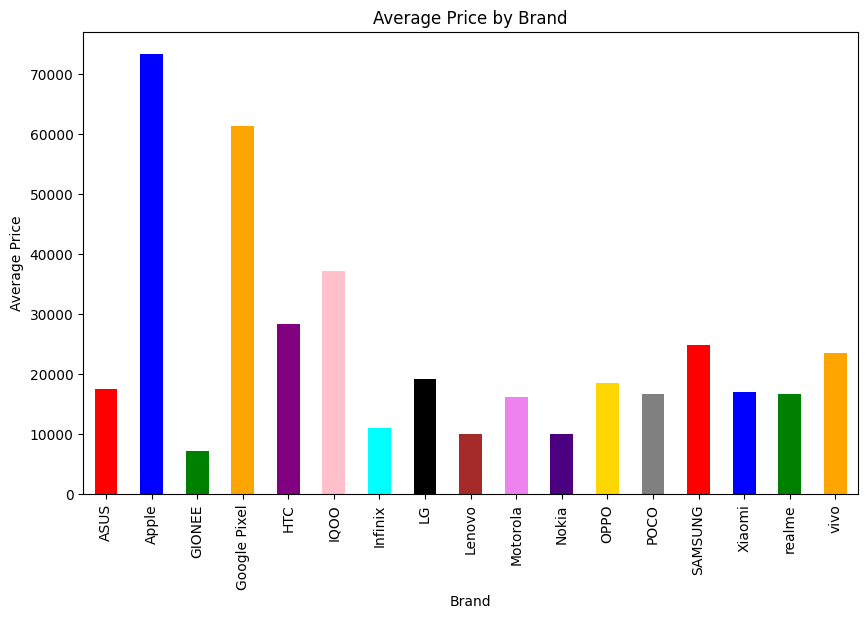

In [16]:
# Chart - 2 visualization code
# Average Price of Each Brand
x=df.groupby('Brand')['Selling Price'].mean()
c=['red','blue','green','orange','purple','pink','cyan','black','brown','violet','indigo','gold','grey']
plt.figure(figsize=(10,6))
x.plot(kind='bar',color=c)
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.title('Average Price by Brand')
plt.show()

##### 1. Why did you pick the specific chart?

Answer :   A bar chart was chosen because it is the most suitable chart for comparing the average selling prices across different brands. It clearly shows the differences in average prices, making it easy to identify which brands are more expensive or affordable

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. The average selling price varies significantly across different brands.
2. Some brands have a much higher average selling price, indicating that they are positioned as premium brands.
3. Other brands have lower average selling prices, suggesting they target budget-conscious customers.
4. The chart helps identify the pricing strategy followed by each brand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer :  Yes, these insights can help businesses understand where each brand stands in the market and adjust their pricing and target audience accordingly. Premium brands can focus on quality, while budget brands can attract price-sensitive customers.

However, higher-priced brands may lose sales if customers find them too expensive, and low-priced brands might struggle with profit unless they sell in large volumes.

#### Chart - 3

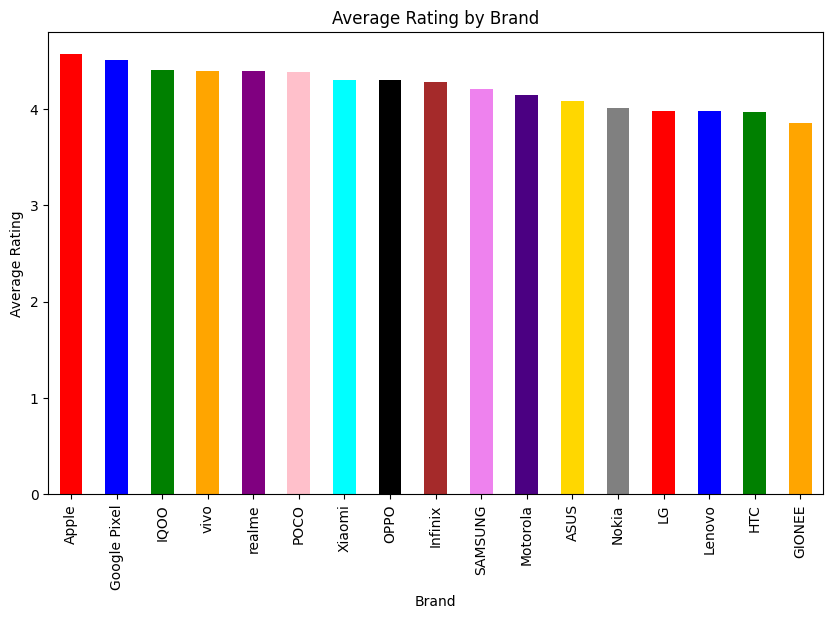

In [17]:
# Chart - 3 visualization code
x=df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)
c=['red','blue','green','orange','purple','pink','cyan','black','brown','violet','indigo','gold','grey']
plt.figure(figsize=(10,6))
x.plot(kind='bar',color=c)
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.title('Average Rating by Brand')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A bar chart was used because it clearly compares the average rating of different brands, making it easy to see which brands perform better or worse.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows that some brands have higher average ratings, indicating better customer satisfaction, while a few brands have relatively lower ratings, showing room for improvement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, these insights help identify strong and weak performing brands, allowing businesses to improve product quality and customer experience. However, low-rated brands may face reduced customer trust and sales if issues are not addressed.

#### Chart - 4

Text(0.5, 1.0, 'Average Discount by Brand')

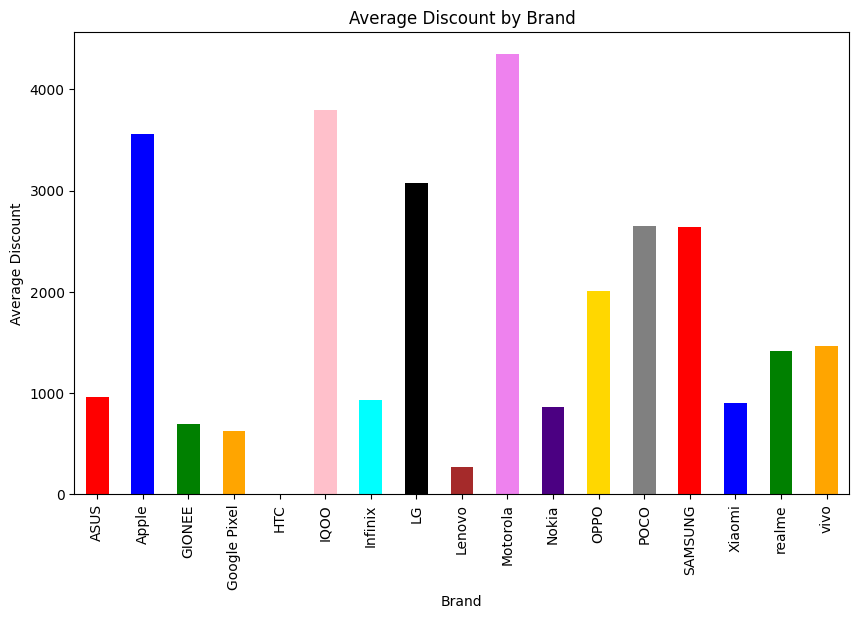

In [18]:
# Chart - 4 visualization code
df['discount']=df['Original Price']-df['Selling Price']
x=df.groupby('Brand')['discount'].mean()
plt.figure(figsize=(10,6))
x.plot(color=c,kind='bar')
plt.xlabel('Brand')
plt.ylabel('Average Discount')
plt.title('Average Discount by Brand')

##### 1. Why did you pick the specific chart?

Answer : A bar chart was chosen because it clearly shows and compares the average discount offered by different brands, making differences easy to understand at a glance.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows which brands are offering higher average discounts and which are offering lower discounts, helping us understand each brand’s pricing and discount strategy.:

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, this helps businesses design better discount strategies to attract customers and increase sales. However, brands giving very low discounts may lose price-sensitive customers, while very high discounts could reduce profit margins.

#### Chart - 5

<Figure size 1000x600 with 0 Axes>

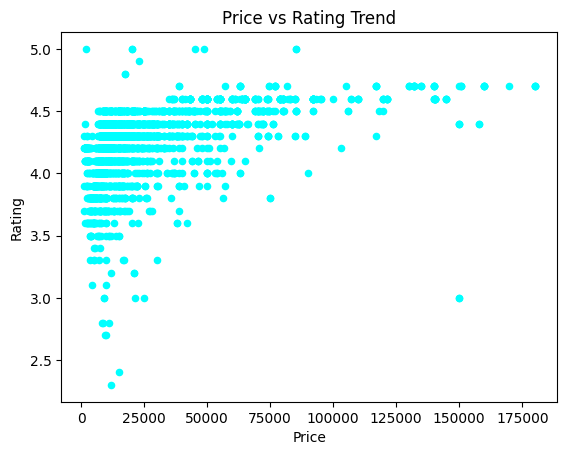

In [19]:
# Chart - 5 visualization code

c='cyan'
plt.figure(figsize=(10,6))
df.plot(x='Selling Price',y='Rating',kind='scatter',color=c)
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs Rating Trend')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A scatter plot was chosen because it helps visualize the relationship between rating and selling price, making it easy to see if higher prices are linked to better ratings.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows that there is no strong direct relationship between price and rating. Some high-priced products have good ratings, but many affordable products also perform well

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, this insight helps businesses understand that higher price does not always guarantee better ratings, so focus should be on quality and customer satisfaction. A negative insight is that some expensive products still receive low ratings, which can harm brand reputation and sales.

#### Chart - 6

<Figure size 1000x600 with 0 Axes>

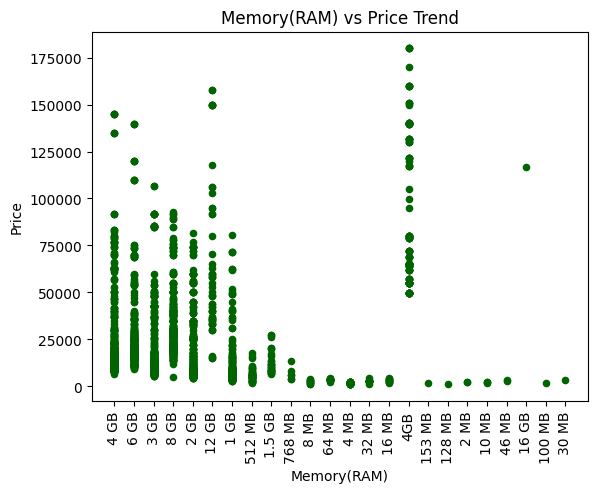

In [48]:
# Chart - 6 visualization code
c='darkgreen'
plt.figure(figsize=(10,6))
df.plot(x='Memory',y='Selling Price',kind='scatter',color=c)
plt.xlabel('Memory(RAM)')
plt.xticks(rotation=90)
plt.ylabel('Price')
plt.title('Memory(RAM) vs Price Trend')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A scatter plot is suitable because it shows the relationship between two numerical variables (Memory/RAM and Selling Price) and helps identify trends, patterns, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. Selling price generally increases as RAM increases.
2. Higher RAM devices tend to have higher prices.
3. Some price variations exist for the same RAM due to other features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes. The insights help in pricing strategy and product positioning, as higher RAM models can be priced at a premium. The price variation within the same RAM category indicates that other factors also influence price, so relying only on RAM for pricing decisions could lead to inaccurate pricing and reduced sales.

#### Chart - 7

<Figure size 1000x600 with 0 Axes>

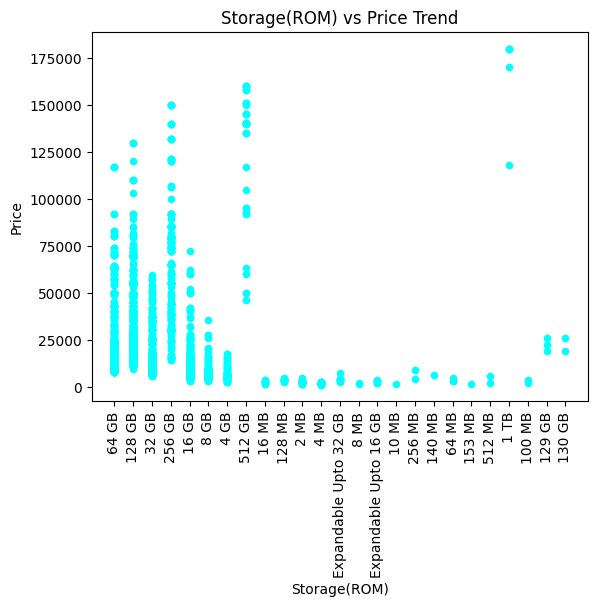

In [32]:
# Chart - 7 visualization code
c='cyan'
plt.figure(figsize=(10,6))

df.plot(x='Storage',y='Selling Price',kind='scatter',color=c)
plt.xlabel('Storage(ROM)')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.title('Storage(ROM) vs Price Trend')
plt.show()



##### 1. Why did you pick the specific chart?

Answer : A scatter plot is appropriate because it shows the relationship between Storage (ROM) and Selling Price and helps identify trends, patterns, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. Selling price generally increases as storage capacity increases.
2. Devices with higher storage are usually more expensive.
3. Some price differences exist within the same storage category due to other features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes. The insights help in pricing products and understanding customer preferences for higher storage variants. However, storage alone does not determine price, so ignoring other factors (such as processor, RAM, or brand) may result in incorrect pricing decisions and reduced sales.

#### Chart - 8

<Figure size 1000x600 with 0 Axes>

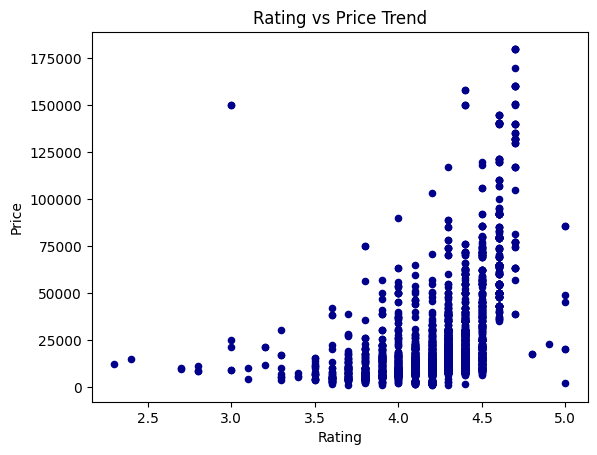

In [47]:
# Chart - 8 visualization code
#
c='darkblue'
plt.figure(figsize=(10,6))

df.plot(x='Rating',y='Selling Price',kind='scatter',color=c)
plt.xlabel('Rating')
plt.ylabel('Price')
plt.xticks(rotation=0)
plt.title('Rating vs Price Trend')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A scatter plot is suitable because it shows the relationship between two numerical variables (Rating and Selling Price) and helps identify trends, patterns, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. Higher-rated phones generally tend to have higher selling prices.
2. The relationship is not perfectly linear, indicating that factors other than rating also affect price.
3. Some high-priced phones have similar ratings to lower-priced phones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes. The insights help businesses understand whether customers associate higher prices with better-rated products, supporting pricing and marketing strategies. However, if expensive phones receive average or low ratings, it may reduce customer satisfaction and negatively affect sales and brand reputation.

#### Chart - 9

<Figure size 1000x600 with 0 Axes>

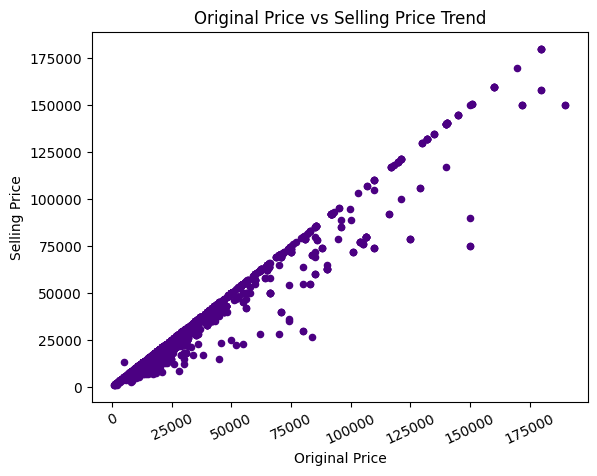

In [44]:
# Chart - 9 visualization code
c=['indigo']
plt.figure(figsize=(10,6))

df.plot(x='Original Price',y='Selling Price',kind='scatter',color=c)
plt.xlabel('Original Price')
plt.ylabel('Selling Price')
plt.xticks(rotation=25)
plt.title('Original Price vs Selling Price Trend')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A scatter plot is suitable because it shows the relationship between the Original Price and Selling Price and helps identify trends, correlations, and outliers.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. Phones with higher original prices generally have higher selling prices.
2. Most selling prices are lower than the original prices, indicating discounts.
3. The discount amount varies across different phones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes. The insights help businesses optimize pricing and discount strategies to attract customers while maintaining profitability. However, very large discounts on certain products may reduce profit margins and could make customers wait for discounts instead of purchasing at the original price.

#### Chart - 10

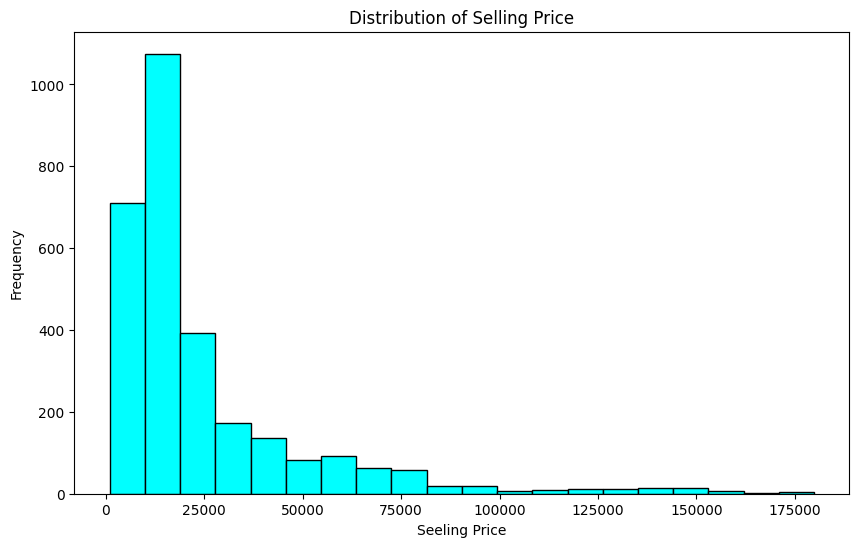

In [54]:
# Chart - 10 visualization code
#HISTOGRAM
plt.figure(figsize=(10,6))
z=df['Selling Price']
z.plot(kind='hist',color='cyan',edgecolor='black',bins=20)
plt.xlabel('Seeling Price')
plt.title('Distribution of Selling Price')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A histogram is used because it helps to understand the distribution of a continuous variable like Selling Price. It clearly shows how prices are spread across different ranges and how frequently each range occurs.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. Most selling prices are concentrated in the lower to mid range.
2. The data is likely right-skewed, meaning a few very high-priced values exist but are rare.
3. It also helps identify possible outliers (very expensive cars).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, it is useful for business decisions like setting optimal price ranges and managing inventory based on demand.

Negative impact:
If high-priced cars are very few in demand, keeping too many of them can lead to slow sales and blocked capital, which may reduce overall profit efficiency.

#### Chart - 11

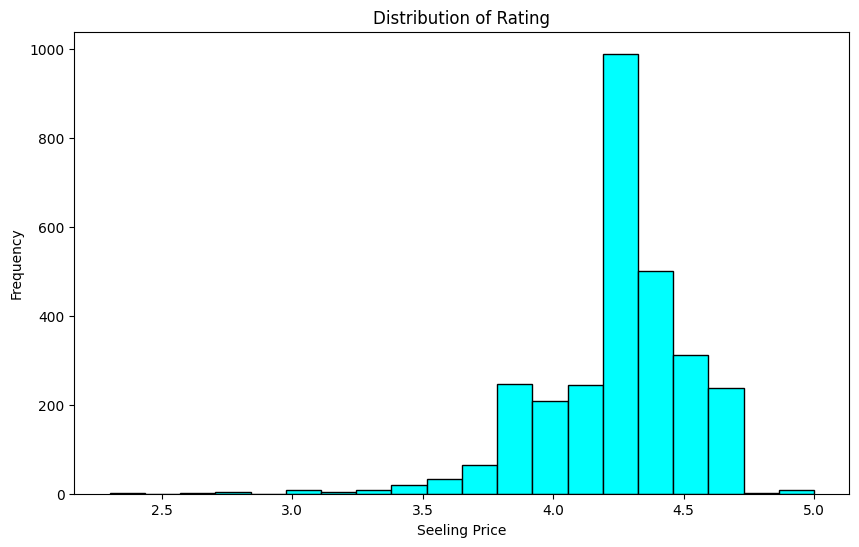

In [56]:
# Chart - 11 visualization code
plt.figure(figsize=(10,6))
z=df['Rating']
z.plot(kind='hist',color='cyan',edgecolor='black',bins=20)
plt.xlabel('Seeling Price')
plt.title('Distribution of Rating')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A histogram is used to understand the distribution of Ratings. It helps to see how ratings are spread across different values and how frequently each rating occurs.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. Most ratings are likely concentrated in the higher range (good ratings).
2. The distribution shows how users generally rate the product (positive, neutral, or mixed).
3. It may also show if there are very low ratings (outliers or dissatisfaction cases).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, it helps in understanding customer satisfaction levels, which can improve product quality and service.

Negative impact:
If there are many low ratings, it indicates customer dissatisfaction, which can hurt brand image and reduce future sales.

#### Chart - 12

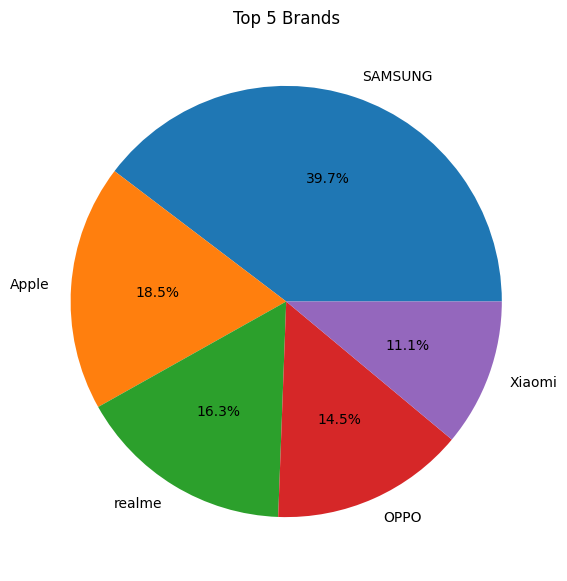

In [70]:
# Chart - 12 visualization code
plt.figure(figsize=(7,7))
z=df['Brand'].value_counts().head(5)

z.plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.title('Top 5 Brands')
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A pie chart is used to show the proportion of top 5 brands in the dataset. It helps compare each brand’s share visually in a simple way.

##### 2. What is/are the insight(s) found from the chart?

Answer :
1. It shows which brands dominate the dataset.
2. A few brands usually hold a large share of listings, while others have smaller presence.
3. Helps identify the most popular brands in the market

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, it helps in marketing and inventory planning by focusing on high-demand brands.

Negative impact:
If one or two brands dominate too much, it may indicate low diversity in inventory, which can limit customer choice and reduce potential market reach.

#### Chart - 13

In [27]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [28]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [29]:
# Pair Plot visualization code

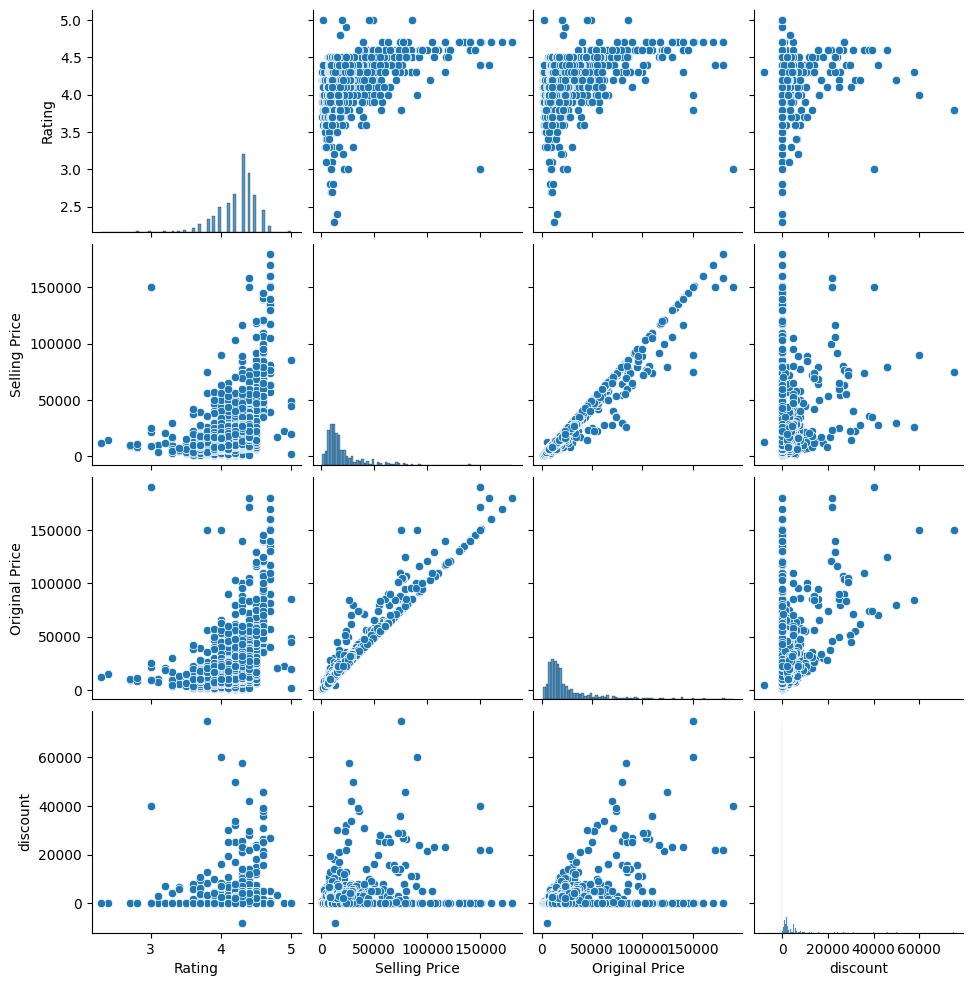

In [30]:
import seaborn as sns
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [31]:
8882582016

8882582016